## Attribute Selection

Workflow:
1. Load processed data
2. Feature selection with SelectKBest (including score visualization)
3. Dimensionality reduction with PCA
4. Compare KBest vs PCA
5. Save reduced datasets

In [1]:
# 1. Load processed data

import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test = pd.read_parquet("../data/processed/X_test.parquet")

y_label_train = pd.read_parquet("../data/processed/y_label_train.parquet")['label']
y_label_test = pd.read_parquet("../data/processed/y_label_test.parquet")['label']

y_cat_train = pd.read_parquet("../data/processed/y_cat_train.parquet")['attack_cat']
y_cat_test = pd.read_parquet("../data/processed/y_cat_test.parquet")['attack_cat']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (64870, 185), X_test: (31952, 185)


In [2]:
# 2. Feature selection with SelectKBest

from sklearn.feature_selection import SelectKBest, f_classif
# mutual_info_classif took to much time, f_classif is faster

k = 50

# KBest for binary target (label)
kbest_label = SelectKBest(score_func=f_classif, k=k)
kbest_label.fit(X_train, y_label_train)
selected_label_cols = X_train.columns[kbest_label.get_support()].tolist()

print(f"Top {k} features for LABEL (binary):")
print(selected_label_cols)

# KBest for multiclass target (attack_cat)
kbest_cat = SelectKBest(score_func=f_classif, k=k)
kbest_cat.fit(X_train, y_cat_train)
selected_cat_cols = X_train.columns[kbest_cat.get_support()].tolist()

X_train_kbest_label = X_train[selected_label_cols]
X_test_kbest_label = X_test[selected_label_cols]

X_train_kbest_cat = X_train[selected_cat_cols]
X_test_kbest_cat = X_test[selected_cat_cols]

print(f"\nTop {k} features for ATTACK_CAT (multiclass):")
print(selected_cat_cols)

Top 50 features for LABEL (binary):
['proto_any', 'proto_arp', 'proto_gre', 'proto_mobile', 'proto_ospf', 'proto_rsvp', 'proto_sctp', 'proto_sep', 'proto_swipe', 'proto_tcp', 'proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp-data', 'service_http', 'service_pop3', 'service_smtp', 'service_ssh', 'service_ssl', 'state_CON', 'state_FIN', 'state_INT', 'state_RST', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_dst_sport_ltm', 'ct_flw_http_mthd', 'is_sm_ips_ports']

Top 50 features for ATTACK_CAT (multiclass):
['proto_arp', 'proto_ospf', 'proto_sctp', 'proto_tcp', 'proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp', 'service_ftp-data', 'service_http', 'service_irc', 'service_pop3', 'service_smtp', 'service_snmp', 'service_ssh', 'state_CON', 'state_FIN', 'state_INT', 'dur', 'spkt

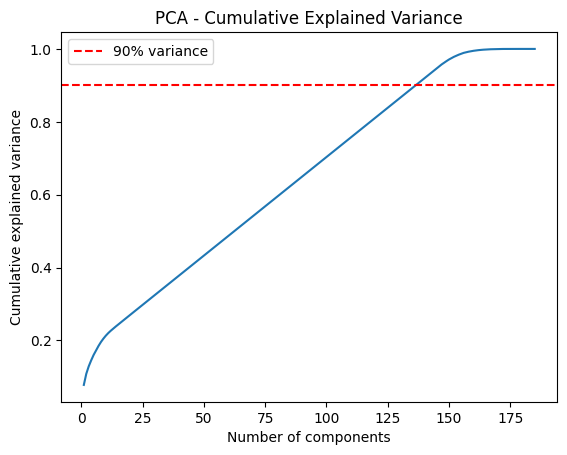

Using the top 137 components to explain 90% of variance
X_train_pca shape: (64870, 137)
X_test_pca shape: (31952, 137)


In [3]:
# 3. Dimensionality reduction with PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

cutoff_variance = 0.90

# Scale data before PCA (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit PCA on train only
pca = PCA(random_state=42)
X_train_pca_full = pca.fit_transform(X_train_scaled)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.axhline(y=cutoff_variance, color='red', linestyle='--', label=f'{cutoff_variance:.0%} variance')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.show()

# Find the number of components needed to reach the cutoff
cutoff_index = np.argmax(cumulative_variance > cutoff_variance)
print(f"Using the top {cutoff_index + 1} components to explain {cutoff_variance:.0%} of variance")

X_train_pca = X_train_pca_full[:, :cutoff_index + 1]
X_test_pca = pca.transform(X_test_scaled)[:, :cutoff_index + 1]

print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

In [4]:
# 4. Compare KBest vs PCA

comparison = pd.DataFrame({
    'Method': ['KBest (label)', 'KBest (attack_cat)', 'PCA'],
    'Original features': [X_train.shape[1]] * 3,
    'Selected/Reduced features': [len(selected_label_cols), len(selected_cat_cols), X_train_pca.shape[1]],
    'Interpretability': ['High (original features)', 'High (original features)', 'Low (linear combinations)'],
    'Target-aware': ['Yes (label)', 'Yes (attack_cat)', 'No (unsupervised)']
})

print(comparison.to_string(index=False))

            Method  Original features  Selected/Reduced features          Interpretability      Target-aware
     KBest (label)                185                         50  High (original features)       Yes (label)
KBest (attack_cat)                185                         50  High (original features)  Yes (attack_cat)
               PCA                185                        137 Low (linear combinations) No (unsupervised)


### Discussion

KBest performs a much more aggressive reduction (30 out of 185 features) but maintains full interpretability. The selected features are the original network traffic attributes, which is very important in a cybersecurity context where is fundamental to understand which signal indicates an attack.

PCA, on the other hand, achieves a limited dimensionality reduction (137 on 185 features needed for 90% cumulative variance - 118 features for 80%). This suggests that the variance is spread across many directions, and that there is low correlation between the many numerical traffic features.

In the next notebook, we will evaluate the optimal representation for classification by training the same models on both KBest and PCA datasets and comparing their F1 scores.

**Note**: while PCA was explored here for comparison, it was excluded from the classification notebooks (04/05) due to impractical computation time during GridSearchCV even with a reduced fixed number of components (k=30). Classification therefore will be done using only KBest-selected features. 

In [5]:
# 5. Save reduced datasets

import os

os.makedirs("../data/reduced", exist_ok = True)

X_train_kbest_label.to_parquet("../data/reduced/X_train_kbest_label.parquet")
X_test_kbest_label.to_parquet("../data/reduced/X_test_kbest_label.parquet")

X_train_kbest_cat.to_parquet("../data/reduced/X_train_kbest_cat.parquet")
X_test_kbest_cat.to_parquet("../data/reduced/X_test_kbest_cat.parquet")

pd.DataFrame(X_train_pca).to_parquet("../data/reduced/X_train_pca.parquet")
pd.DataFrame(X_test_pca).to_parquet("../data/reduced/X_test_pca.parquet")


print("Reduced datasets saved to ../data/reduced")

Reduced datasets saved to ../data/reduced
